# **1. Setup and Device Configuration**

Necessary libraries (torch, torch.nn, torch.optim, torchvision, matplotlib.pyplot, numpy) are imported, and based on the availability of a suitable GPU/CPU, the computations will be performed.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# **2. Data Loading and Preparation**

A transformation is defined that converts images to tensors using PyTorch (transforms.ToTensor()). Next, the dataset for training and testing purposes is downloaded and loaded from the source. The DataLoader is used in order to perform shuffling/batching operations during model training.

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=10, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 509kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.21MB/s]


# **3. Adding Artificial Noise Function**

The code cell defines an add_noise function. This function takes a batch of images as input and adds random noise to those images, and then uses a clamp operation to ensure the validity of the image data values.

In [3]:
def add_noise(imgs, noise_factor=0.5):
    noisy_imgs = imgs + noise_factor * torch.randn_like(imgs)
    noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)
    return noisy_imgs

# **4. Denoising Autoencoder Model Definition**

This cell specifies the structure of the DenoisingAutoencoder class that utilizes a CNN. The structure includes the encoder part (Conv2d layer followed by ReLU and MaxPool2d) that encodes the image and the decoder part (ConvTranspose2d layer, ReLU, and Sigmoid) that decodes the encoded image. This cell also creates the model instance and initializes its loss function (nn.BCELoss) and its optimizer (optim.Adam).

In [4]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = DenoisingAutoencoder().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# **5. Training Loop with Validation**

This cell represents the main loop. It repeats training for the specified number of epochs. During each epoch, it runs training procedure (add noise, forward pass, loss computation, backward pass, optimizer step) and evaluation on the testing dataset.

In [5]:
epochs = 20
train_losses = []
val_losses = []

print("Training Denoising Autoencoder...")

for epoch in range(epochs):
    # Training Phase
    model.train()
    running_train_loss = 0.0

    for data in train_loader:
        clean_imgs, _ = data
        noisy_imgs = add_noise(clean_imgs).to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()
        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * clean_imgs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation Phase
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for data in test_loader:
            clean_imgs, _ = data
            noisy_imgs = add_noise(clean_imgs).to(device)
            clean_imgs = clean_imgs.to(device)

            outputs = model(noisy_imgs)
            loss = criterion(outputs, clean_imgs)
            running_val_loss += loss.item() * clean_imgs.size(0)

    epoch_val_loss = running_val_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"Epoch {epoch+1}/{epochs} \t Train Loss: {epoch_train_loss:.4f} \t Val Loss: {epoch_val_loss:.4f}")

Training Denoising Autoencoder...
Epoch 1/20 	 Train Loss: 0.2320 	 Val Loss: 0.1287
Epoch 2/20 	 Train Loss: 0.1235 	 Val Loss: 0.1186
Epoch 3/20 	 Train Loss: 0.1183 	 Val Loss: 0.1157
Epoch 4/20 	 Train Loss: 0.1159 	 Val Loss: 0.1141
Epoch 5/20 	 Train Loss: 0.1145 	 Val Loss: 0.1129
Epoch 6/20 	 Train Loss: 0.1135 	 Val Loss: 0.1119
Epoch 7/20 	 Train Loss: 0.1126 	 Val Loss: 0.1112
Epoch 8/20 	 Train Loss: 0.1120 	 Val Loss: 0.1105
Epoch 9/20 	 Train Loss: 0.1114 	 Val Loss: 0.1101
Epoch 10/20 	 Train Loss: 0.1108 	 Val Loss: 0.1099
Epoch 11/20 	 Train Loss: 0.1104 	 Val Loss: 0.1092
Epoch 12/20 	 Train Loss: 0.1099 	 Val Loss: 0.1087
Epoch 13/20 	 Train Loss: 0.1096 	 Val Loss: 0.1082
Epoch 14/20 	 Train Loss: 0.1093 	 Val Loss: 0.1082
Epoch 15/20 	 Train Loss: 0.1089 	 Val Loss: 0.1079
Epoch 16/20 	 Train Loss: 0.1087 	 Val Loss: 0.1079
Epoch 17/20 	 Train Loss: 0.1085 	 Val Loss: 0.1074
Epoch 18/20 	 Train Loss: 0.1084 	 Val Loss: 0.1072
Epoch 19/20 	 Train Loss: 0.1081 	 Val 

# **6. Visualizing the Learning Curve**

This cell employs matplotlib to generate a “Learning Curve” graph showing how the losses of the training and validation phases evolve throughout the training process. In addition, the learning curve enables an assessment of whether any problem such as overfitting has occurred in the training phase.

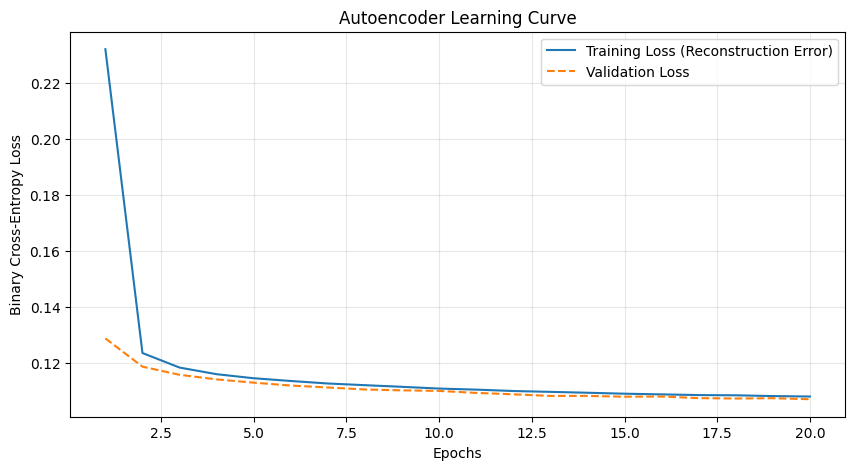

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss (Reconstruction Error)')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', linestyle='--')
plt.title('Autoencoder Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **7. Evaluating and Visualizing Results**

The following cell evaluates the performance of our model by generating side-by-side images containing the original, noise-added input images and their denoised versions generated by the autoencoder.

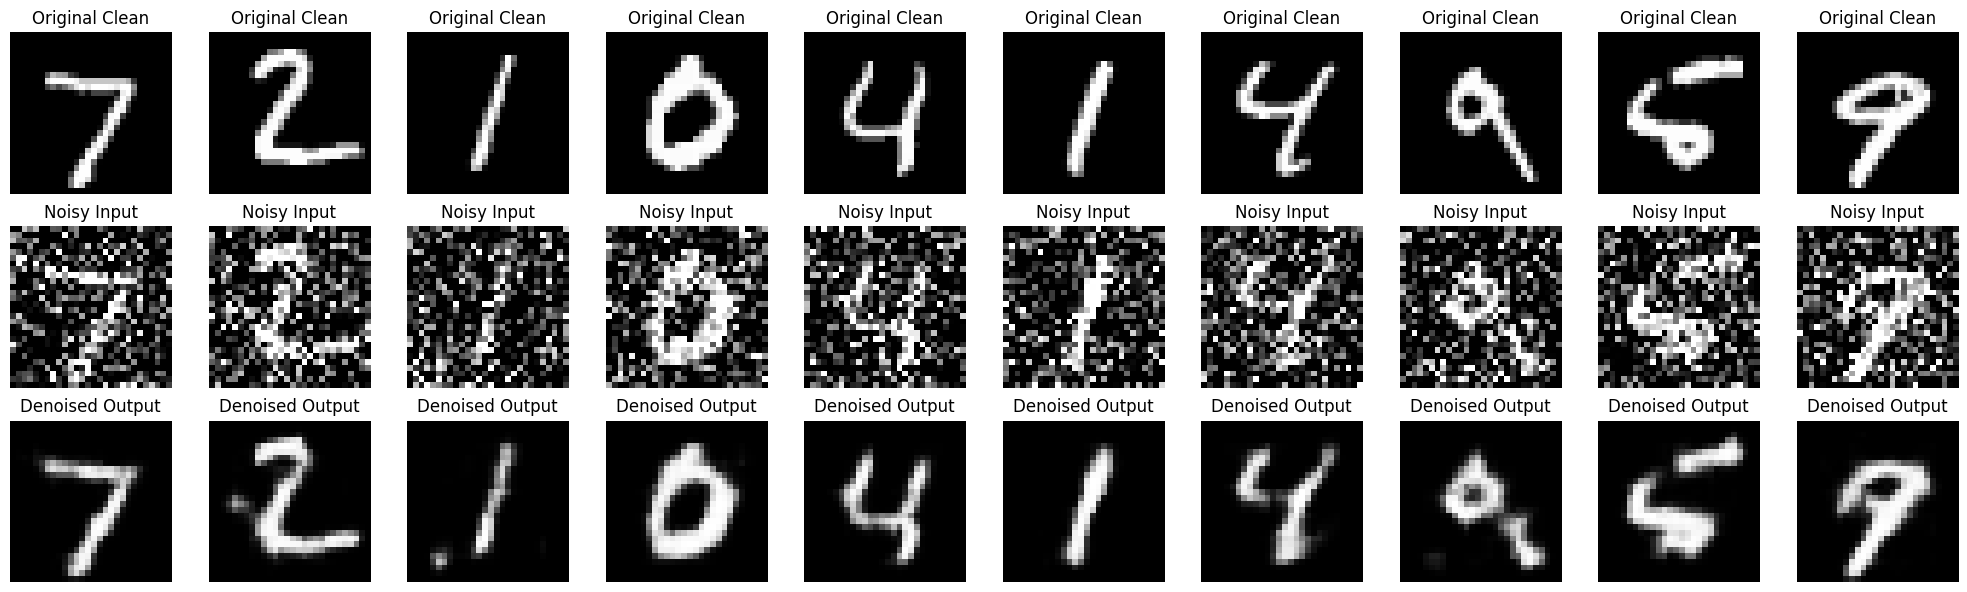

In [7]:
model.eval()
dataiter = iter(test_loader)
clean_test_imgs, _ = next(dataiter)
noisy_test_imgs = add_noise(clean_test_imgs).to(device)

with torch.no_grad():
    denoised_test_imgs = model(noisy_test_imgs)

clean_test_imgs = clean_test_imgs.numpy()
noisy_test_imgs = noisy_test_imgs.cpu().numpy()
denoised_test_imgs = denoised_test_imgs.cpu().numpy()

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original Clean Images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(np.squeeze(clean_test_imgs[i]), cmap='gray')
    plt.title("Original Clean")
    plt.axis("off")

    # Noisy Input Images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(np.squeeze(noisy_test_imgs[i]), cmap='gray')
    plt.title("Noisy Input")
    plt.axis("off")

    # Denoised Output Images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(np.squeeze(denoised_test_imgs[i]), cmap='gray')
    plt.title("Denoised Output")
    plt.axis("off")

plt.tight_layout()
plt.show()